#  Ecommerce Customer Churn Prediction

### End-to-End Machine Learning Project using XGBoost

---

##  Project Overview

This project focuses on predicting whether an e-commerce customer is likely to churn based on their demographic, behavioral, transactional, engagement, and customer-service-related information.

The project follows an end-to-end machine learning workflow including:

- Data Understanding & Auditing
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Feature Engineering
- Feature Selection & Analysis
- Preprocessing using Scikit-learn Pipelines
- Model Comparison
- XGBoost Model Training
- Cross-Validation
- Hyperparameter Tuning
- Model Evaluation
- Threshold Optimization
- Business-Oriented Churn Prediction

---

##  Problem Statement

Customer churn is an important business problem for e-commerce companies because losing existing customers can reduce revenue and increase customer acquisition costs.

The objective of this project is to build a machine learning classification model that can identify customers who are at risk of leaving the platform.

The model uses customer demographics, membership information, login behavior, transaction activity, wallet points, complaints, feedback, and engagement patterns to estimate the probability of customer churn.

### Business Goal

The primary goal is to identify high-risk customers early so that the business can take targeted retention actions such as personalized offers, customer support, discounts, or engagement campaigns.

---

##  Business Objectives

- Identify customers with a high probability of churn.
- Detect churn-risk customers at an early stage.
- Reduce customer attrition.
- Support targeted retention campaigns.
- Reduce unnecessary retention efforts.
- Improve customer retention and lifetime value.

---

##  Final Model

**Model:** XGBoost Classifier

**Final Pipeline:** `XGBoost_Pipeline`

**Classification Threshold:** `0.55`

The complete preprocessing and XGBoost model are combined into a single Scikit-learn pipeline to ensure consistent preprocessing during training and deployment.

## 1. Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load dataset

In [2]:
df = pd.read_csv('/content/churn.csv')


In [3]:
df.head()

,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,18,F,XW0DQ7H,Village,Platinum Membership,17-08-2017,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,17,300.63,53005.25,17,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,32,F,5K0N3X1,City,Premium Membership,28-08-2017,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16,306.34,12838.38,10,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,44,F,1F2TCL3,Town,No Membership,11-11-2016,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,14,516.16,21027.00,22,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,37,M,VJGJ33N,City,No Membership,29-10-2016,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,11,53.27,25239.56,6,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,31,F,SVZXCWB,City,No Membership,12-09-2017,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,20,113.13,24483.66,16,663.06,No,Yes,Yes,Solved,Poor Website,1


## 3. Initial data audit

In [4]:
print('Shape:', df.shape)

Shape: (36992, 23)


In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           36992 non-null  int64  
 1   gender                        36992 non-null  object 
 2   security_no                   36992 non-null  object 
 3   region_category               31564 non-null  object 
 4   membership_category           36992 non-null  object 
 5   joining_date                  36992 non-null  object 
 6   joined_through_referral       36992 non-null  object 
 7   referral_id                   36992 non-null  object 
 8   preferred_offer_types         36704 non-null  object 
 9   medium_of_operation           36992 non-null  object 
 10  internet_option               36992 non-null  object 
 11  last_visit_time               36992 non-null  object 
 12  days_since_last_login         36992 non-null  int64  
 13  a

In [6]:
df.columns

Index(['age', 'gender', 'security_no', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
age,0
gender,0
security_no,0
region_category,5428
membership_category,0
joining_date,0
joined_through_referral,0
referral_id,0
preferred_offer_types,288
medium_of_operation,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,36992.000000,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000
mean,37.118161,-41.915576,243.472334,29271.194003,686.882199,0.540982
std,15.867412,228.819900,398.289149,19444.806226,194.063624,0.498324
min,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,0.000000
25%,23.000000,8.000000,60.102500,14177.540000,616.150000,0.000000
50%,37.000000,12.000000,161.765000,27554.485000,697.620000,1.000000
75%,51.000000,16.000000,356.515000,40855.110000,763.950000,1.000000
max,64.000000,26.000000,3235.578521,99914.050000,2069.069761,1.000000


In [10]:
df.describe(include='object')

,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,avg_frequency_login_days,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback
count,36992,36992,31564,36992,36992,36992,36992,36704,36992,36992,36992,36992,36992,36992,36992,36992,36992
unique,3,36992,3,6,1096,3,11359,3,4,3,30101,1654,2,2,2,5,9
top,F,TDTN42Y,Town,Basic Membership,02-06-2015,No,xxxxxxxx,Gift Vouchers/Coupons,Desktop,Wi-Fi,7:56:41,Error,Yes,Yes,No,Not Applicable,Poor Product Quality
freq,18490,1,14128,7724,55,15839,17846,12349,13913,12413,6,3522,20342,20440,18602,18602,6350


In [11]:
print(f"Total Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Total Memory Usage: 35.66 MB


In [12]:
df.nunique()

,0
age,55
gender,3
security_no,36992
region_category,3
membership_category,6
joining_date,1096
joined_through_referral,3
referral_id,11359
preferred_offer_types,3
medium_of_operation,4


## 4. Target variable analysis

In [13]:
df['churn_risk_score'].value_counts(normalize=True)

,proportion
churn_risk_score,
1,0.540982
0,0.459018


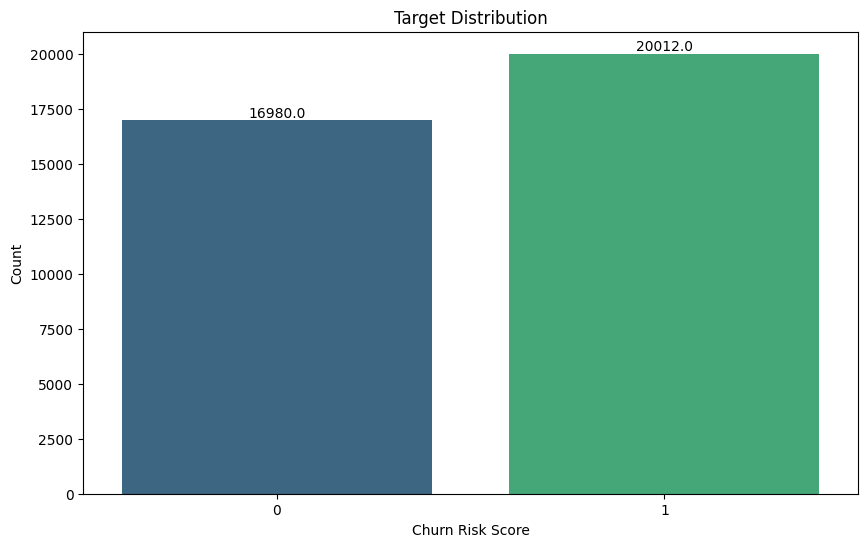

In [14]:
plt.figure(figsize=(10, 6))
ex = sns.countplot(x='churn_risk_score', data=df,palette='viridis')
plt.title('Target Distribution')
plt.xlabel('Churn Risk Score')
plt.ylabel('Count')

# Add count values on top of the bars with simpler annotation
for p in ex.patches:
    ex.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.show()

## 5. Feature engineering

### 5.1 Customer tenure from joining date

In [15]:
df['joining_date'] = pd.to_datetime(df['joining_date'])

reference_date = df['joining_date'].max()

df['customer_tenure_days'] = (reference_date - df['joining_date']).dt.days

df.drop(columns=['joining_date'], inplace=True)

df[['customer_tenure_days']].head()

,customer_tenure_days
0,136
1,125
2,415
3,428
4,110


### 5.2 Visit hour from last visit time

In [16]:
df['last_visit_time'] = pd.to_datetime(
    df['last_visit_time'],
    format='%H:%M:%S',
    errors='coerce'
)

df['visit_hour'] = df['last_visit_time'].dt.hour

df.drop(columns=['last_visit_time'], inplace=True)

df[['visit_hour']].head()

,visit_hour
0,16
1,12
2,22
3,15
4,15


### 5.3 Convert avg_frequency_login_days to numeric

In [17]:
df['avg_frequency_login_days'] = pd.to_numeric(
    df['avg_frequency_login_days'],
    errors='coerce'
)

df['avg_frequency_login_days'].dtype

dtype('float64')

## 6. Remove identifier columns

In [18]:
df = df.drop(columns=['security_no', 'referral_id'])
df.head()

,age,gender,region_category,membership_category,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,customer_tenure_days,visit_hour
0,18,F,Village,Platinum Membership,No,Gift Vouchers/Coupons,?,Wi-Fi,17,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0,136,16
1,32,F,City,Premium Membership,?,Gift Vouchers/Coupons,Desktop,Mobile_Data,16,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,0,125,12
2,44,F,Town,No Membership,Yes,Gift Vouchers/Coupons,Desktop,Wi-Fi,14,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1,415,22
3,37,M,City,No Membership,Yes,Gift Vouchers/Coupons,Desktop,Mobile_Data,11,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1,428,15
4,31,F,City,No Membership,No,Credit/Debit Card Offers,Smartphone,Mobile_Data,20,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1,110,15


## 7. Numerical and categorical column audit

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print('Numerical columns:')
print(numeric_cols)

print('\nCategorical columns:')
print(categorical_cols)

Numerical columns:
Index(['age', 'days_since_last_login', 'avg_time_spent',
       'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet',
       'churn_risk_score', 'customer_tenure_days', 'visit_hour'],
      dtype='object')

Categorical columns:
Index(['gender', 'region_category', 'membership_category',
       'joined_through_referral', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback'],
      dtype='object')


In [20]:
df[numeric_cols].isnull().sum()

,0
age,0
days_since_last_login,0
avg_time_spent,0
avg_transaction_value,0
avg_frequency_login_days,3522
points_in_wallet,3443
churn_risk_score,0
customer_tenure_days,0
visit_hour,0


In [21]:
df[categorical_cols].isnull().sum()

,0
gender,0
region_category,5428
membership_category,0
joined_through_referral,0
preferred_offer_types,288
medium_of_operation,0
internet_option,0
used_special_discount,0
offer_application_preference,0
past_complaint,0


## 8. Correlation analysis

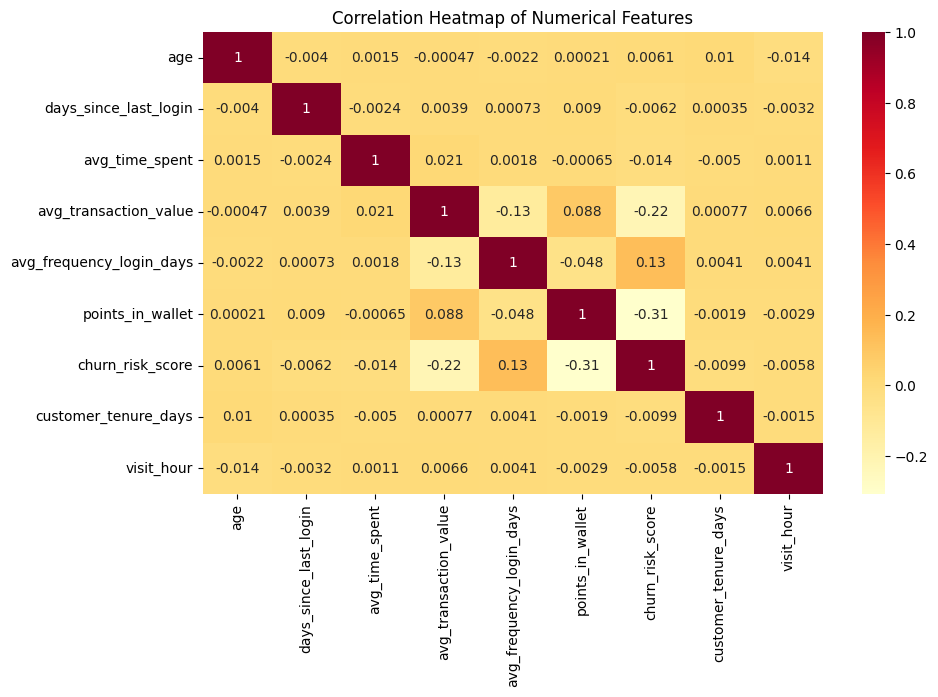

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='YlOrRd')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 9. Categorical association with target (Cramér&apos;s V)

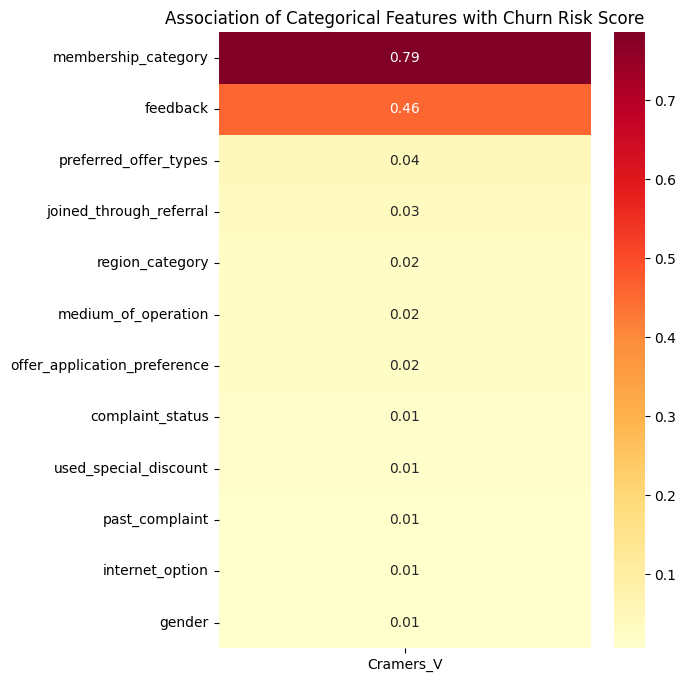

In [23]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))

target = 'churn_risk_score'

cat_target_assoc = {}
for col in categorical_cols:
    cat_target_assoc[col] = cramers_v(df[col], df[target])

cat_target_assoc = (
    pd.Series(cat_target_assoc)
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,8))
sns.heatmap(cat_target_assoc.to_frame(name='Cramers_V'),
            annot=True,
            fmt='.2f',
            cmap='YlOrRd')

plt.title('Association of Categorical Features with Churn Risk Score')
plt.show()

## 10. Data cleaning

### 10.1 Handle invalid numerical values

In [24]:
df['days_since_last_login'] = df['days_since_last_login'].replace(-999, np.nan)

df.loc[df['avg_time_spent'] < 0, 'avg_time_spent'] = np.nan

df.loc[df['points_in_wallet'] < 0, 'points_in_wallet'] = 0

### 10.2 Clean categorical placeholders

In [25]:
df['gender'] = df['gender'].replace('Unknown', np.nan)
df['joined_through_referral'] = df['joined_through_referral'].replace('?', np.nan)
df['medium_of_operation'] = df['medium_of_operation'].replace('?', np.nan)

### 10.3 Clip impossible login frequency values

In [26]:
df['avg_frequency_login_days'] = df['avg_frequency_login_days'].clip(lower=0)

### 10.4 IQR-based outlier clipping

In [27]:
clip_cols = [
    'avg_transaction_value',
    'points_in_wallet',
    'avg_frequency_login_days'
]

for col in clip_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if col == 'avg_frequency_login_days':
        lower = max(lower, 0)

    df[col] = df[col].clip(lower=lower, upper=upper)

print('Outlier clipping completed.')

Outlier clipping completed.


In [28]:
q1 = df['avg_time_spent'].quantile(0.25)
q3 = df['avg_time_spent'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 *iqr
upper = q3 + 1.5 *iqr

df['avg_time_spent'] = df['avg_time_spent'].clip(lower=lower,upper=upper)

## 11. Distribution plots after cleaning

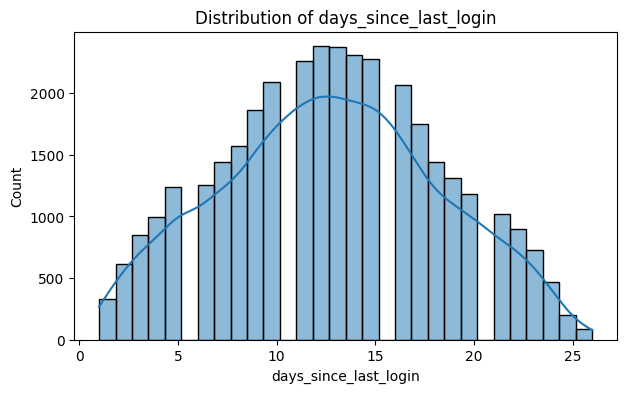

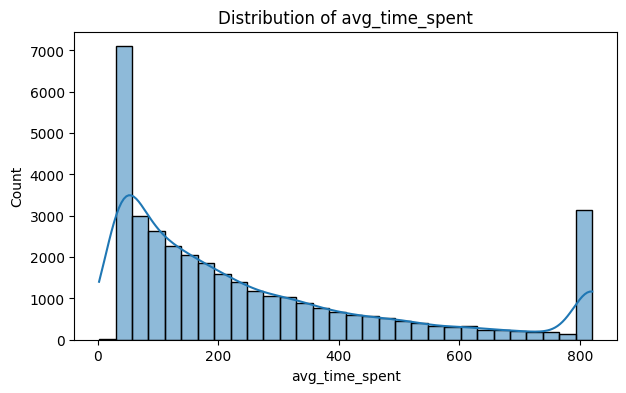

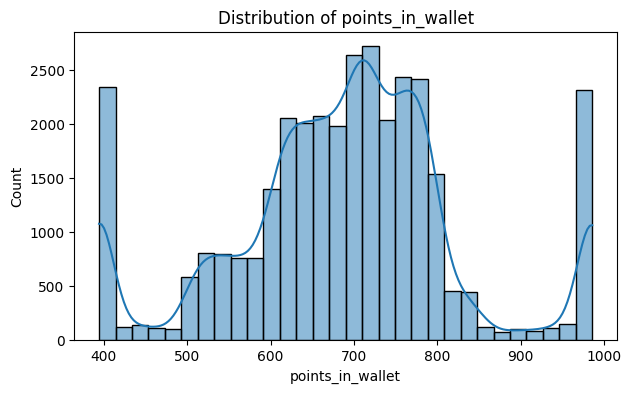

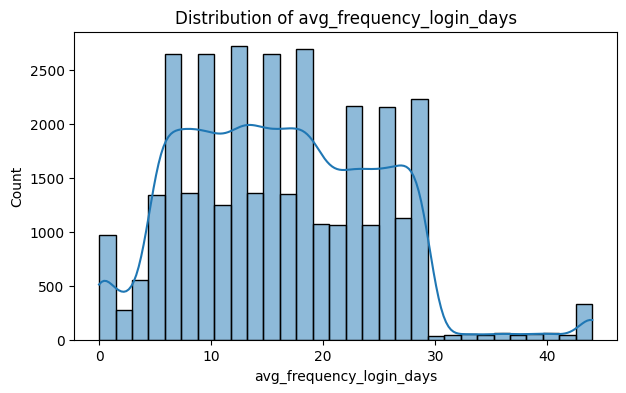

In [29]:
for col in ['days_since_last_login', 'avg_time_spent', 'points_in_wallet', 'avg_frequency_login_days']:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

## 12. Final missing-value summary

Note: **Do not impute missing values manually here.** We will use `SimpleImputer` inside a scikit-learn pipeline after the train-test split to avoid data leakage.

In [30]:
df.isnull().sum().sort_values(ascending=False)

,0
joined_through_referral,5438
region_category,5428
medium_of_operation,5393
avg_frequency_login_days,3522
points_in_wallet,3443
days_since_last_login,1999
avg_time_spent,1719
preferred_offer_types,288
gender,59
membership_category,0


## 13. Data Splitting: Features, Target, Train-Test Split

In [31]:
X = df.drop(columns = ['churn_risk_score'])
y = df['churn_risk_score']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (29593, 20)
Shape of X_test: (7399, 20)
Shape of y_train: (29593,)
Shape of y_test: (7399,)


In [33]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
churn_risk_score
1    0.540973
0    0.459027
Name: proportion, dtype: float64

Test distribution:
churn_risk_score
1    0.541019
0    0.458981
Name: proportion, dtype: float64


## 14. Preprocessing Pipeline Setup

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.pipeline import Pipeline

In [35]:
# Target already separated

# 1. Skewed numerical features (log transform + scaling)
skewed_col = [
    'avg_time_spent',
    'avg_transaction_value',
    'points_in_wallet',
    'customer_tenure_days'
]

# 2. Normal numerical features (only scaling)
other_numeric_cols = [
    'age',
    'days_since_last_login',
    'avg_frequency_login_days',
    'visit_hour'
]

# 3. Ordinal categorical feature (order matters)
ordinal_col = ['membership_category']

# 4. Nominal categorical features (no order)
normal_col = [
    'gender',
    'region_category',
    'joined_through_referral',
    'preferred_offer_types',
    'medium_of_operation',
    'internet_option',
    'used_special_discount',
    'offer_application_preference',
    'past_complaint',
    'complaint_status',
    'feedback'
]

In [36]:
skew_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scale',StandardScaler())
])

plain_numeric_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scale',StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=[[
        'No Membership',
        'Basic Membership',
        'Silver Membership',
        'Gold Membership',
        'Platinum Membership',
        'Premium Membership'
    ]]))
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('Skewed_Pipeline', skew_pipeline, skewed_col),
        ('Plain_Numeric', plain_numeric_pipeline, other_numeric_cols),
        ('Ordinal', ordinal_pipeline, ordinal_col),
        ('Nominal', nominal_pipeline, normal_col)
    ]
)


In [37]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [38]:
print(type(X_train_processed))
print(X_train_processed.shape)
print(X_test_processed.shape)

<class 'numpy.ndarray'>
(29593, 45)
(7399, 45)


## 15. Model Training and Evaluation (Baseline)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [40]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.01,
        max_depth=6,
        min_child_weight=3,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        probability=True,
        random_state=42
    ))
])

In [41]:
models = {
    "LR_model":logistic_pipeline,
    "RF_model":random_forest_pipeline,
    "XGB_model":xgboost_pipeline,
    "DT_model":decision_tree_pipeline,
    "KNN_model":knn_pipeline,
    "SVM_model":svm_pipeline
}


In [43]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

print("All models trained successfully!")

Training LR_model...
Training RF_model...
Training XGB_model...
Training DT_model...
Training KNN_model...
Training SVM_model...
All models trained successfully!


In [47]:


for name, model in models.items():

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Classification Report
    report = classification_report(y_test, y_pred)

    print("=" * 70)
    print(f"MODEL: {name}")
    print("=" * 70)

    print(f"Accuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    print(report)

    print("Confusion Matrix:")
    print(cm)

    print("\n")

MODEL: LR_model
Accuracy: 0.8475

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      3396
           1       0.85      0.88      0.86      4003

    accuracy                           0.85      7399
   macro avg       0.85      0.85      0.85      7399
weighted avg       0.85      0.85      0.85      7399

Confusion Matrix:
[[2766  630]
 [ 498 3505]]


MODEL: RF_model
Accuracy: 0.9316

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3396
           1       0.94      0.94      0.94      4003

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399

Confusion Matrix:
[[3144  252]
 [ 254 3749]]


MODEL: XGB_model
Accuracy: 0.9365

Classification Report:
              precision    recall  f1-score   support

           0       0.92  

## 16. XGBoost Model Development and Hyperparameter Tuning

In [49]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgboost_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

Cross Validation Scores: [0.93613786 0.93326575 0.93799628 0.93511321 0.94102737]
Mean CV Accuracy: 0.9367080973336049
Std CV Accuracy: 0.0026470406966148077


In [54]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgboost_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'classifier__subsample': 0.9, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 5, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.9}

Best CV Accuracy:
0.9366065746996416


In [58]:
XGBoost_Pipeline = random_search.best_estimator_

In [118]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Churn probability
y_prob = XGBoost_Pipeline.predict_proba(X_test)[:, 1]

# Custom threshold
CHURN_THRESHOLD = 0.50

# Final prediction using 0.50 threshold
y_pred = (y_prob >= CHURN_THRESHOLD).astype(int)

print("Final XGBoost Model")
print("Churn Threshold:", CHURN_THRESHOLD)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Final XGBoost Model
Churn Threshold: 0.5

Accuracy: 0.934720908230842

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      3396
           1       0.94      0.94      0.94      4003

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399


Confusion Matrix:
[[3173  223]
 [ 260 3743]]

ROC-AUC: 0.9755238047318457


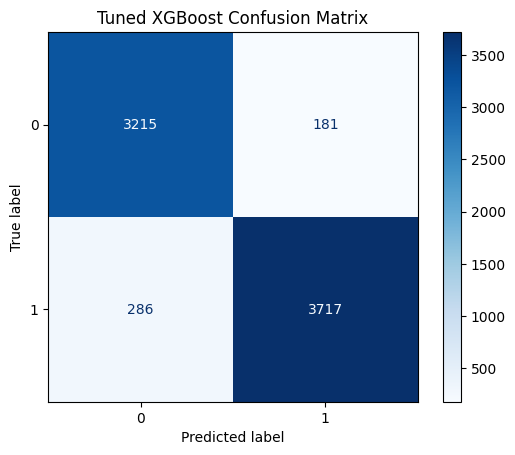

In [88]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Tuned XGBoost Confusion Matrix')
plt.show()

## 17. Make Predictions on New Data

In [63]:
test_df_2 = pd.DataFrame({

    "membership_category": [
        "Premium Membership",
        "Gold Membership",
        "Silver Membership",
        "Basic Membership",
        "Platinum Membership",
        "Gold Membership",
        "No Membership",
        "Silver Membership",
        "Premium Membership",
        "Basic Membership"
    ],

    "age": [
        26, 41, 34, 29, 52,
        23, 47, 38, 31, 44
    ],

    "gender": [
        "M", "F", "M", "F", "M",
        "F", "M", "F", "M", "F"
    ],

    "region_category": [
        "City", "Town", "Village", "City", "Town",
        "Village", "City", "Town", "Village", "City"
    ],

    "joined_through_referral": [
        "Yes", "No", "Yes", "No", "Yes",
        "Yes", "No", "Yes", "No", "Yes"
    ],

    "preferred_offer_types": [
        "Credit/Debit Card Offers",
        "Gift Vouchers/Coupons",
        "Without Offers",
        "Gift Vouchers/Coupons",
        "Credit/Debit Card Offers",
        "Without Offers",
        "Gift Vouchers/Coupons",
        "Credit/Debit Card Offers",
        "Without Offers",
        "Gift Vouchers/Coupons"
    ],

    "medium_of_operation": [
        "Smartphone", "Both", "Desktop", "Smartphone", "Both",
        "Desktop", "Smartphone", "Both", "Desktop", "Smartphone"
    ],

    "internet_option": [
        "Fiber_Optic", "Wi-Fi", "Mobile_Data", "Fiber_Optic", "Wi-Fi",
        "Mobile_Data", "Fiber_Optic", "Wi-Fi", "Mobile_Data", "Fiber_Optic"
    ],

    "avg_time_spent": [
        82.5, 640.2, 48.7, 312.4, 175.8,
        920.6, 35.4, 410.3, 128.9, 265.7
    ],

    "avg_transaction_value": [
        1850.4, 720.8, 245.6, 1380.5, 3200.7,
        460.3, 190.2, 2150.8, 980.4, 610.7
    ],

    "points_in_wallet": [
        420.5, 812.7, 385.2, 705.4, 1120.8,
        290.6, 180.4, 920.3, 510.7, 340.9
    ],

    "used_special_discount": [
        "Yes", "No", "Yes", "Yes", "No",
        "Yes", "No", "Yes", "No", "Yes"
    ],

    "offer_application_preference": [
        "Yes", "No", "Yes", "No", "Yes",
        "Yes", "No", "No", "Yes", "Yes"
    ],

    "past_complaint": [
        "Yes", "Yes", "No", "Yes", "Yes",
        "No", "Yes", "No", "Yes", "Yes"
    ],

    "complaint_status": [
        "Solved", "Unsolved", "Not Applicable",
        "Unsolved", "Solved in Follow-up",
        "Not Applicable", "Unsolved", "Not Applicable",
        "Solved", "Solved in Follow-up"
    ],

    "feedback": [
        "Poor Customer Service",
        "Reasonable Price",
        "User Friendly Website",
        "Too many ads",
        "Poor Product Quality",
        "Products always in Stock",
        "Poor Website",
        "Reasonable Price",
        "Too many ads",
        "Poor Customer Service"
    ],

    "days_since_last_login": [
        4, 21, 8, 17, 3,
        12, 25, 7, 19, 14
    ],

    "avg_frequency_login_days": [
        3.2, 18.6, 6.4, 14.8, 2.7,
        9.5, 21.3, 5.8, 16.9, 11.7
    ],

    "customer_tenure_days": [
        420, 980, 610, 350, 1420,
        290, 1180, 760, 540, 1050
    ],

    "visit_hour": [
        22, 9, 18, 14, 21,
        11, 23, 8, 20, 16
    ]
})

In [87]:
pred = XGBoost_Pipeline.predict(test_df_2)

prob = XGBoost_Pipeline.predict_proba(test_df_2)[:, 1]

test_result = test_df_2[["membership_category", "age"]].copy()

test_result["Predicted_Churn"] = pred
test_result["Churn_Probability"] = np.round(prob, 3)

test_result

,membership_category,age,Predicted_Churn,Churn_Probability
0,Premium Membership,26,0,0.002
1,Gold Membership,41,0,0.005
2,Silver Membership,34,0,0.097
3,Basic Membership,29,1,0.980
4,Platinum Membership,52,0,0.003
5,Gold Membership,23,0,0.116
6,No Membership,47,1,0.961
7,Silver Membership,38,0,0.229
8,Premium Membership,31,0,0.003
9,Basic Membership,44,1,0.936


#Import PickleFile

In [89]:
import joblib

# Save complete XGBoost pipeline
joblib.dump(
    XGBoost_Pipeline,
    "XGBoost_Pipeline.pkl"
)

print("XGBoost_Pipeline.pkl saved successfully!")

XGBoost_Pipeline.pkl saved successfully!


#  Project Conclusion & Business Impact

##  Conclusion

This project successfully developed an end-to-end machine learning solution for predicting customer churn in an e-commerce environment.

The complete workflow included data auditing, exploratory data analysis, data cleaning, feature engineering, preprocessing, model comparison, cross-validation, hyperparameter tuning, and final model evaluation.

The final XGBoost pipeline demonstrated strong classification performance and was selected as the final model for customer churn prediction.

---

##  Final Model Performance

The final model achieved strong performance across multiple evaluation metrics, including:

- Accuracy: ~93.47%
- Precision: ~94.38%
- Recall: ~93.50%
- F1-Score: ~93.94%
- ROC-AUC: ~97.55%

These results indicate that the model can effectively distinguish between customers who are likely to churn and customers who are likely to remain active.

---

## Business Impact

The model can help an e-commerce business:

- Identify high-risk customers before they churn.
- Prioritize customers for retention campaigns.
- Reduce unnecessary marketing efforts.
- Provide personalized offers to high-risk customers.
- Improve customer retention.
- Support data-driven customer relationship management.

---

##  Final Business Decision Threshold

A classification threshold of **0.50** was used for the final prediction system.

### Decision Rule

- **Churn Probability ≥ 0.50 → Churn Risk (1)**
- **Churn Probability < 0.50 → Not Churn (0)**

The 0.50 threshold provides a strong balance between precision and recall for the final e-commerce churn prediction system.

---

##  Final Model

The final model is stored as:

`XGBoost_Pipeline.pkl`

The saved pipeline contains the complete preprocessing workflow together with the trained XGBoost model, allowing the same preprocessing and prediction process to be used on new customer data.

---

##  Deployment Readiness

The trained pipeline can be integrated into a web application or API to provide real-time churn predictions for new customers.

The deployment system can return:

- Churn Prediction
- Churn Probability
- Customer Risk Status

---

##  Future Improvements

- Monitor model performance after deployment.
- Retrain the model periodically with new customer data.
- Add SHAP-based prediction explanations.
- Implement customer-level retention recommendations.
- Monitor data drift and model drift.
- Integrate the prediction system with an e-commerce CRM/retention workflow.

---

#  Final Takeaway

This project demonstrates a complete machine learning workflow from raw customer data to a deployment-ready churn prediction pipeline.

The solution combines **machine learning performance with business-oriented decision making**, allowing an e-commerce business to proactively identify customers who may be at risk of churn and take appropriate retention actions.